In [34]:
#Money-Market Rates | Quantitative Portfolio Management & Algorithmic Trading Part II

In [35]:
# 1: Plot the time series

In [36]:
from pathlib import Path
DATA = (Path.home() / "OneDrive - The University of Chicago"
        / "Algorithmic_Trading_&_Quantitative_Portfolio_Management"
        / ".Resources" / "data")
FILE = DATA / "ref_rates.xlsx"

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 14

DATA_DIR = (Path.home()
            / "OneDrive - The University of Chicago"
            / "Algorithmic_Trading_&_Quantitative_Portfolio_Management"
            / ".Resources" / "data")

REF_RATES = DATA_DIR / "ref_rates.xlsx"
SPY_DAILY = DATA_DIR / "spy_data_daily.xlsx"

assert REF_RATES.exists(), f"Not found: {REF_RATES}"
assert SPY_DAILY.exists(), f"Not found: {SPY_DAILY}"

In [38]:
info = pd.read_excel(REF_RATES, sheet_name='info')
info

,description,ticker (FRED)
0,Tbill 3-month,DTB3
1,Fed Funds Effective,DFF
2,SOFR,SOFR


In [39]:
rates = pd.read_excel(REF_RATES, sheet_name='data',
                      index_col='date', parse_dates=True)

rates = rates.rename(columns={
    'DTB3': 'T-bill 3M',
    'DFF':  'Fed Funds',
    'SOFR': 'SOFR',
})

# shortest maturity first
rates = rates[['SOFR', 'Fed Funds', 'T-bill 3M']]
rates.head()

,SOFR,Fed Funds,T-bill 3M
date,,,
2018-01-01,NaN,1.33,NaN
2018-01-02,NaN,1.42,1.42
2018-01-03,NaN,1.42,1.39
2018-01-04,NaN,1.42,1.39
2018-01-05,NaN,1.42,1.37


In [40]:
coverage = pd.DataFrame({
    'first obs': rates.apply(lambda c: c.first_valid_index()),
    'last obs':  rates.apply(lambda c: c.last_valid_index()),
    'n obs':     rates.notna().sum(),
    'n missing': rates.isna().sum(),
    'weekend obs': [rates[c].dropna().index.dayofweek.isin([5, 6]).sum()
                    for c in rates.columns],
})
coverage

,first obs,last obs,n obs,n missing,weekend obs
SOFR,2018-04-03,2026-06-05,2042,1036,0
Fed Funds,2018-01-01,2026-06-04,3077,1,878
T-bill 3M,2018-01-02,2026-06-04,2106,972,0


In [41]:
rates.loc['2024-03-01':'2024-03-05']
# Fed funds is published every calendar day, the Fed carries Friday's rate through the weekdn.
# SOFR and the T-bill only print on business days.

,SOFR,Fed Funds,T-bill 3M
date,,,
2024-03-01,5.31,5.33,5.23
2024-03-02,NaN,5.33,NaN
2024-03-03,NaN,5.33,NaN
2024-03-04,5.31,5.33,5.24
2024-03-05,5.31,5.33,5.23


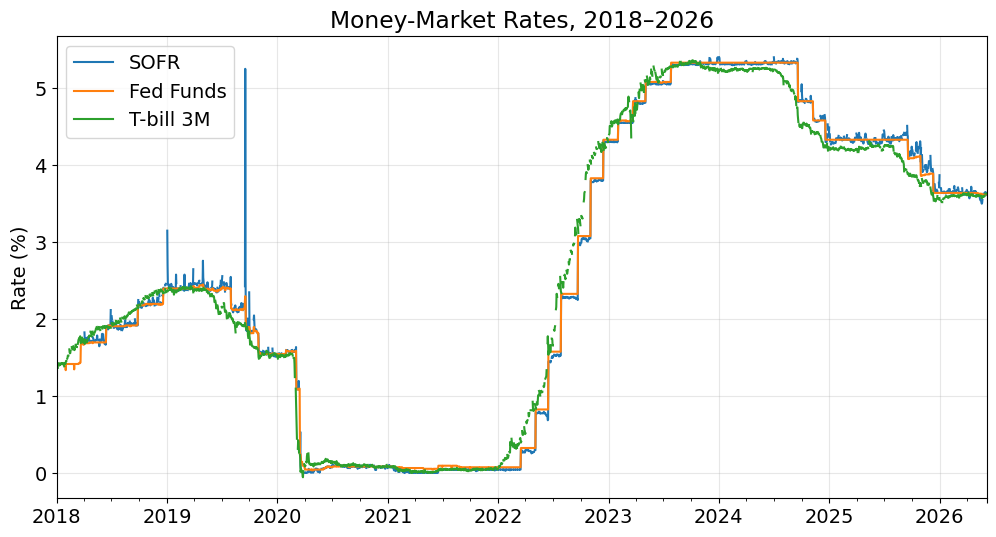

In [42]:
ax = rates.plot(title='Money-Market Rates, 2018–2026')
ax.set_ylabel('Rate (%)')
ax.set_xlabel('')
ax.grid(alpha=0.3)
ax.legend(title=None)
plt.show()

In [43]:
rates.describe().round(3)

,SOFR,Fed Funds,T-bill 3M
count,2042.000,3077.000,2106.000
mean,2.649,2.619,2.616
std,1.952,1.922,1.882
min,0.010,0.040,-0.050
25%,0.280,0.330,0.695
50%,2.400,2.380,2.370
75%,4.360,4.330,4.250
max,5.400,5.330,5.360


In [44]:
# 2 Calculate correlation between the three rates - levels & differences

In [45]:
# Filter to dates where all three report
common = rates.dropna()
print(f"{len(common)} common dates: "
      f"{common.index.min():%Y-%m-%d} to {common.index.max():%Y-%m-%d}") #%Y-%m-%d = date format

corr_levels = common.corr()
corr_levels.round(4)

2041 common dates: 2018-04-03 to 2026-06-04


,SOFR,Fed Funds,T-bill 3M
SOFR,1.0000,0.9991,0.9929
Fed Funds,0.9991,1.0000,0.9947
T-bill 3M,0.9929,0.9947,1.0000


In [46]:
diffs = common.diff().dropna()
corr_diffs = diffs.corr()
corr_diffs.round(4)

,SOFR,Fed Funds,T-bill 3M
SOFR,1.0000,0.4965,0.0375
Fed Funds,0.4965,1.0000,0.0080
T-bill 3M,0.0375,0.0080,1.0000


In [47]:
diag = pd.DataFrame({
    'std of daily chg (bp)': diffs.std() * 100,
    '% of days unchanged':   (diffs == 0).mean() * 100,
}).round(2)
diag

,std of daily chg (bp),% of days unchanged
SOFR,10.69,44.51
Fed Funds,4.98,90.00
T-bill 3M,3.26,31.72


In [48]:
# 3 Estimate an autoregression for SOFR

In [49]:
sofr = common['SOFR']

ar_data = pd.DataFrame({'r_t': sofr, 'r_lag': sofr.shift(1)}).dropna()

X = sm.add_constant(ar_data['r_lag'])
ar1 = sm.OLS(ar_data['r_t'], X).fit()
print(ar1.summary())

                            OLS Regression Results                            
Dep. Variable:                    r_t   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 6.778e+05
Date:                Mon, 03 Aug 2026   Prob (F-statistic):               0.00
Time:                        08:53:59   Log-Likelihood:                 1667.0
No. Observations:                2040   AIC:                            -3330.
Df Residuals:                    2038   BIC:                            -3319.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0048      0.004      1.204      0.2

In [50]:
b, se = ar1.params['r_lag'], ar1.bse['r_lag']
print(f"beta = {b:.5f}  (se {se:.5f})")
print(f"t-stat for H0: beta = 1  ->  {(b - 1)/se:.2f}")

half_life = np.log(0.5) / np.log(b)
print(f"implied half-life: {half_life:.0f} business days ({half_life/252:.1f} years)")

beta = 0.99852  (se 0.00121)
t-stat for H0: beta = 1  ->  -1.22
implied half-life: 467 business days (1.9 years)


In [51]:
d_sofr = sofr.diff().dropna()
dd = pd.DataFrame({'x_t': d_sofr, 'x_lag': d_sofr.shift(1)}).dropna()
ar1_diff = sm.OLS(dd['x_t'], sm.add_constant(dd['x_lag'])).fit()

print(f"beta = {ar1_diff.params['x_lag']:.4f}   R2 = {ar1_diff.rsquared:.4f}")

beta = -0.2502   R2 = 0.0626


In [52]:
# 4 Estimate an autoregression for returns of the S&P 500

In [53]:
spy_ret = pd.read_excel(SPY_DAILY, sheet_name='total returns',
                        index_col='date', parse_dates=True)['SPY'].dropna()
spy_px  = pd.read_excel(SPY_DAILY, sheet_name='prices',
                        index_col='date', parse_dates=True)['SPY'].dropna()

print(f"{len(spy_ret)} obs, {spy_ret.index.min():%Y-%m-%d} to {spy_ret.index.max():%Y-%m-%d}")

8165 obs, 1994-01-04 to 2026-06-12


In [54]:
def ar1_fit(series, label):
    """Estimate y_t = alpha + beta*y_(t-1) + eps_t"""
    d = pd.DataFrame({'y': series, 'lag': series.shift(1)}).dropna()
    m = sm.OLS(d['y'], sm.add_constant(d['lag'])).fit()
    b, se = m.params['lag'], m.bse['lag']
    return pd.Series({
        'n':        int(m.nobs),
        'alpha':    m.params['const'],
        'beta':     b,
        'R2':       m.rsquared,
        't(b=0)':   b / se,
        't(b=1)':   (b - 1) / se,
    }, name=label)

results = pd.DataFrame([
    ar1_fit(common['SOFR'],              'SOFR (level)'),
    ar1_fit(common['SOFR'].diff().dropna(), 'SOFR (change)'),
    ar1_fit(spy_px,                      'SPY (price)'),
    ar1_fit(spy_ret,                     'SPY (return)'),
]).T
results.round(5)

,SOFR (level),SOFR (change),SPY (price),SPY (return)
n,2040.00000,2039.00000,8165.00000,8164.00000
alpha,0.00480,0.00114,-0.01616,0.00052
beta,0.99852,-0.25019,1.00059,-0.08288
R2,0.99700,0.06261,0.99976,0.00687
t(b=0),823.28645,-11.66474,5829.89632,-7.51322
t(b=1),-1.22221,-58.28908,3.43639,-98.16842


In [55]:
# SPY prices autocorrelated? Overwhelmingly — β = 1.0006, R² = 0.9998.
# Prices are essentially a random walk, just like SOFR's level.

# SPY returns autocorrelated? β = −0.083, R² = 0.0069. The lag explains 0.7% of the variance in daily returns.
# Returns are very close to unforecastable.